Epoch 1 - Loss: 1170942208.0000
Epoch 2 - Loss: inf
Epoch 3 - Loss: 31052735533442335891624611859660800.0000
Epoch 4 - Loss: 30928656803304762226671472638689280.0000
Epoch 5 - Loss: 30805068297422745572307193470910464.0000


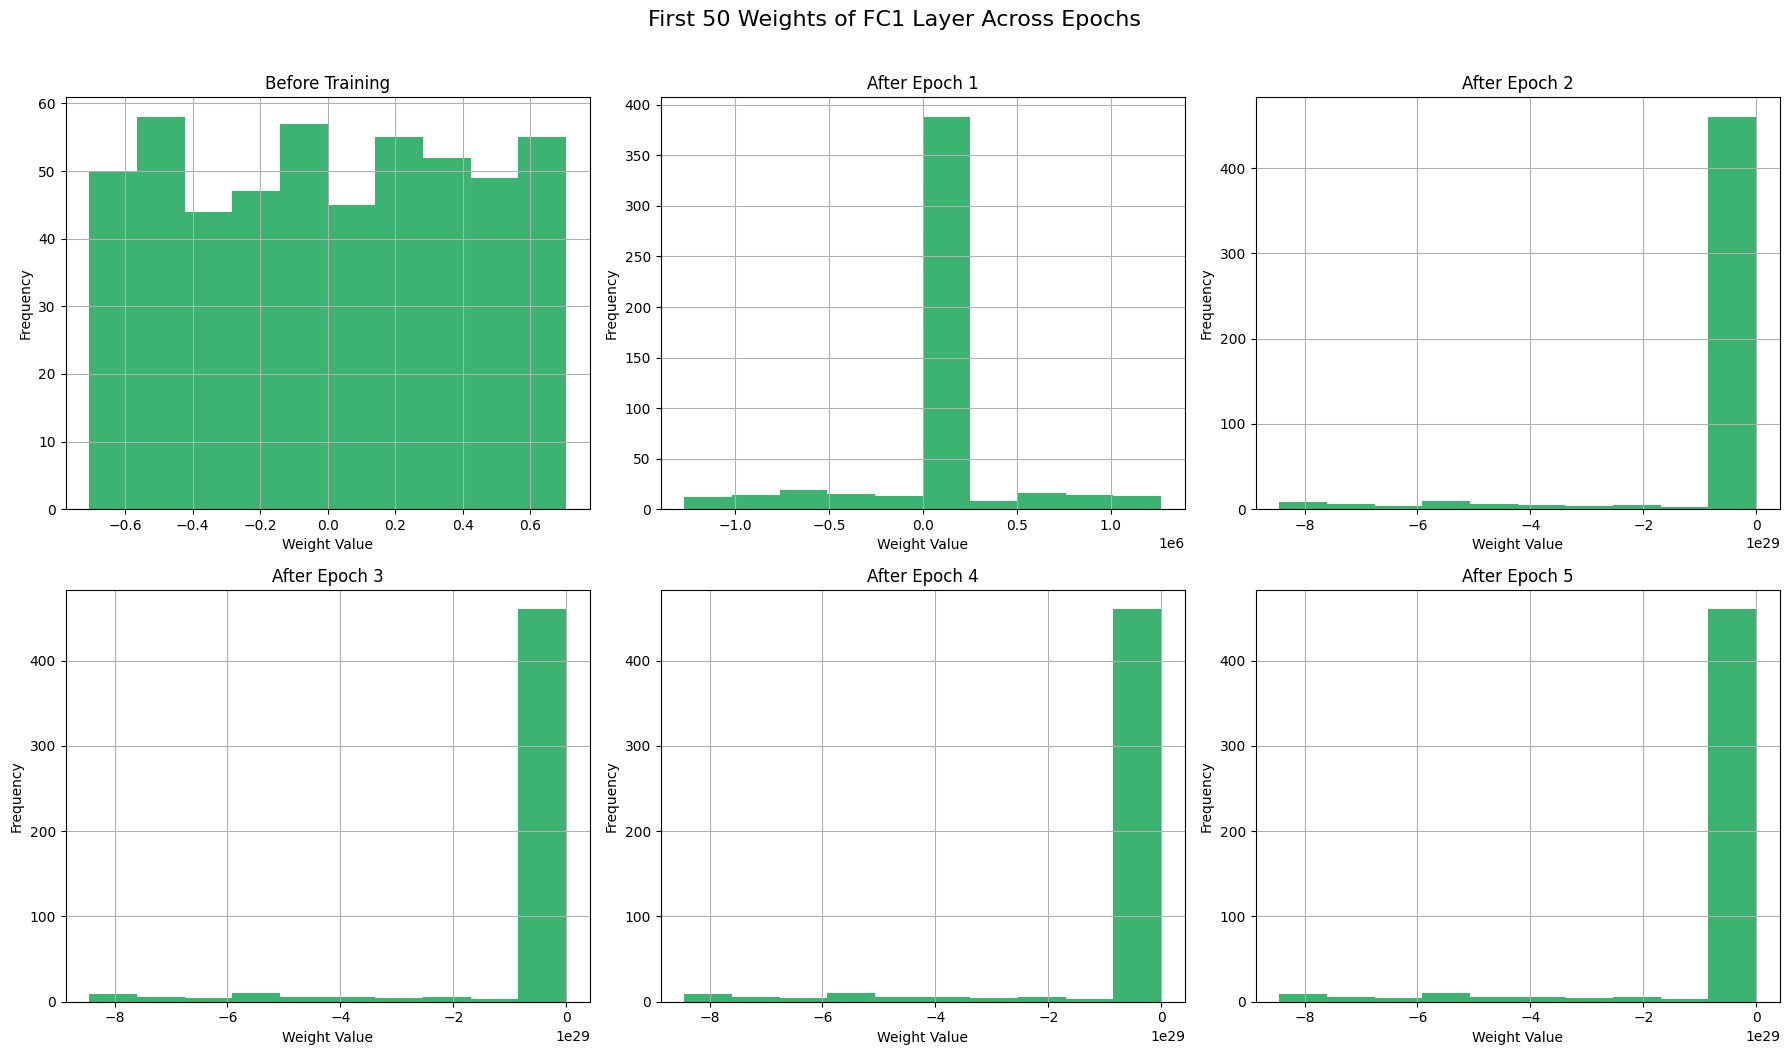

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


# --- Step 1: Generate synthetic raw data ---
np.random.seed(42)
x1 = np.random.uniform(50000, 500000, size=(1000, 1))  # Car mileage
x2 = np.random.uniform(18, 90, size=(1000, 1))         # Driver age
x = np.hstack((x1, x2)).astype(np.float32)
y = np.random.uniform(0, 1, size=(1000, 1)).astype(np.float32)
#x = scaler.fit_transform(x)
inputs = torch.tensor(x)
targets = torch.tensor(y)

# --- Step 2: Define network with BatchNorm ---
class SimpleBNNet(nn.Module):
    def __init__(self):
        super(SimpleBNNet, self).__init__()
        self.fc1 = nn.Linear(2, 256)
       # self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.fc1(x)
      #  x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# --- Step 3: Initialize model, optimizer, and loss ---
model = SimpleBNNet()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- Step 4: Save FC1 weights after each epoch ---
weights_epochs = []
weights_epochs.append(model.fc1.weight.data.clone().detach().numpy().flatten())

# --- Step 5: Train for 5 epochs and track weights ---
for epoch in range(5):
    model.train()
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    weights = model.fc1.weight.data.clone().detach().numpy().flatten()
    weights_epochs.append(weights)

    print(f"Epoch {epoch+1} - Loss: {loss.item():.4f}")

# --- Step 6: Plot histograms of weights over epochs ---
plt.figure(figsize=(18, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.hist(weights_epochs[i], bins=10, color='mediumseagreen')  # Plot only first 50 weights for readability
    title = "Before Training" if i == 0 else f"After Epoch {i}"
    plt.title(title)
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.suptitle("First 50 Weights of FC1 Layer Across Epochs", fontsize=16, y=1.05)
plt.show()
